In [ ]:
pip install pyeit numpy scipy matplotlib pandas scikit-learn opencv-python -q

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os

import pyeit.mesh as mesh
import pyeit.eit.protocol as protocol
import pyeit.eit.jac as jac

from pyeit.eit.fem import EITForward
from pyeit.mesh.wrapper import PyEITAnomaly_Circle

In [2]:
# -----------------------------
# Basic EIT configuration
# -----------------------------

n_el = 16          # number of electrodes
h0 = 0.03      # mesh size; smaller value = finer mesh
# background_perm = 1.0
# edema_perm = 1.5   # edema conductivity; higher than background

# Current injection and voltage measurement protocol
protocol_obj = protocol.create(
    n_el=n_el,
    dist_exc=1,        # adjacent current injection
    step_meas=1,       # adjacent voltage measurement
    parser_meas="std"
)

print("Protocol created successfully")

Protocol created successfully


In [3]:
# -----------------------------
# Create 2D circular FEM mesh
# -----------------------------

mesh_obj = mesh.create(n_el=n_el, h0=h0)

node = mesh_obj.node
element = mesh_obj.element
el_pos = mesh_obj.el_pos

print("Number of nodes:", node.shape)
print("Number of elements:", element.shape)
print("Electrode positions:", el_pos.shape)

Number of nodes: (4057, 3)
Number of elements: (7901, 3)
Electrode positions: (16,)


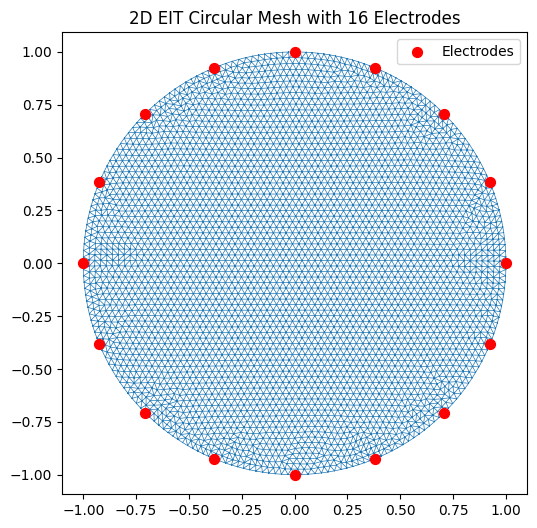

In [4]:
plt.figure(figsize=(6, 6))
plt.triplot(node[:, 0], node[:, 1], element, linewidth=0.5)
plt.scatter(node[el_pos, 0], node[el_pos, 1], c='red', s=50, label="Electrodes")
plt.title("2D EIT Circular Mesh with 16 Electrodes")
plt.axis("equal")
plt.legend()
plt.show()

In [5]:
def create_edema_case(center=(0.35, 0.25), radius=0.20, edema_perm=1.5):
    anomaly = PyEITAnomaly_Circle(
        center=np.array(center),
        r=radius,
        perm=edema_perm
    )

    mesh_edema = mesh.set_perm(
        mesh_obj,
        anomaly=anomaly,
        background=background_perm
    )

    return mesh_edema, anomaly

In [ ]:
# edema_center = (0.6, 0.6)
# edema_radius = 0.1
# edema_conductivity = 1.5

# mesh_edema, anomaly = create_edema_case(
#     center=edema_center,
#     radius=edema_radius,
#     edema_perm=edema_conductivity
# )

# print("Edema case created successfully")
# print("Conductivity values:", np.unique(mesh_edema.perm))

In [6]:
import copy
import numpy as np

# ---------------------------------------------------------
# 50 edema case generation
# Only this edema/data-generation part is changed.
# PINN model, loss style, and training cells below are kept the same.
# ---------------------------------------------------------

BASE_SIGMA_FAT = 0.022       # S/m
BASE_SIGMA_MUSCLE = 0.34     # S/m
BASE_SIGMA_EDEMA = 0.045     # S/m

CONDUCTIVITY_VARIATION = 0.10   # ±10%
MUSCLE_BOUNDARY = 0.80          # radius-based layer division, not sqrt(area)
N_CASES = 50

# Edema size variation.
# These values are kept small because edema is only in the outer 20% fat layer.
EDEMA_RADIUS_RANGE = (0.035, 0.100)

# Minimum number of triangular elements that must be affected by edema.
MIN_EDEMA_ELEMENTS = 20


def create_layered_leg_with_edema(
    mesh_obj,
    edema_center=(0.90, 0.10),
    edema_radius=0.06,
    sigma_fat=BASE_SIGMA_FAT,
    sigma_muscle=BASE_SIGMA_MUSCLE,
    sigma_edema=BASE_SIGMA_EDEMA,
    muscle_boundary=MUSCLE_BOUNDARY
):
    """
    Create a two-layer 2D leg cross-section:
    - Inner 80% radius = muscle
    - Outer 20% radius = fat/subcutaneous layer
    - Edema is injected only inside the fat layer

    Important:
    r_norm is used only for masks.
    Neural input later remains only (x, y).
    """

    node = mesh_obj.node[:, :2]
    element = mesh_obj.element

    # Element centers
    elem_center = np.mean(node[element], axis=1)
    x = elem_center[:, 0]
    y = elem_center[:, 1]

    # Radius normalization around mesh center
    cx = np.mean(node[:, 0])
    cy = np.mean(node[:, 1])

    r_elem = np.sqrt((x - cx)**2 + (y - cy)**2)
    r_node = np.sqrt((node[:, 0] - cx)**2 + (node[:, 1] - cy)**2)
    r_max = np.max(r_node)
    r_norm = r_elem / r_max

    # Radius-based layers
    muscle_mask = r_norm <= muscle_boundary
    fat_mask = r_norm > muscle_boundary

    # Healthy layered conductivity
    perm_healthy = np.zeros(element.shape[0], dtype=np.float32)
    perm_healthy[muscle_mask] = sigma_muscle
    perm_healthy[fat_mask] = sigma_fat

    # Edema candidate, clipped/restricted to fat layer only
    edema_center = np.asarray(edema_center, dtype=np.float32)
    dist_from_edema = np.sqrt((x - edema_center[0])**2 + (y - edema_center[1])**2)
    edema_mask_raw = dist_from_edema <= edema_radius
    edema_mask = edema_mask_raw & fat_mask

    # Diseased conductivity
    perm_edema = perm_healthy.copy()
    perm_edema[edema_mask] = sigma_edema

    mesh_healthy = copy.deepcopy(mesh_obj)
    mesh_diseased = copy.deepcopy(mesh_obj)

    mesh_healthy.perm = perm_healthy
    mesh_diseased.perm = perm_edema

    print("Layered leg model created")
    print("Muscle elements:", np.sum(muscle_mask))
    print("Fat elements:", np.sum(fat_mask))
    print("Edema elements:", np.sum(edema_mask))
    print("sigma_muscle:", sigma_muscle)
    print("sigma_fat:", sigma_fat)
    print("sigma_edema:", sigma_edema)
    print("Delta sigma max:", sigma_edema - sigma_fat)
    print("Healthy conductivity values:", np.unique(perm_healthy))
    print("Diseased conductivity values:", np.unique(perm_edema))

    return mesh_healthy, mesh_diseased, muscle_mask, fat_mask, edema_mask


def _element_geometry_for_sampling(mesh_obj):
    node = mesh_obj.node[:, :2]
    element = mesh_obj.element
    elem_center = np.mean(node[element], axis=1)

    cx = np.mean(node[:, 0])
    cy = np.mean(node[:, 1])

    r_elem = np.sqrt((elem_center[:, 0] - cx)**2 + (elem_center[:, 1] - cy)**2)
    r_node = np.sqrt((node[:, 0] - cx)**2 + (node[:, 1] - cy)**2)
    r_norm = r_elem / np.max(r_node)

    fat_mask = r_norm > MUSCLE_BOUNDARY

    return elem_center, fat_mask


def generate_edema_cases(mesh_obj, n_cases=50, seed=42):
    """
    Generate n edema cases:
    - different positions in fat layer
    - varying edema size
    - muscle/fat/edema conductivities varied by ±10%
    """
    rng = np.random.default_rng(seed)
    elem_center, fat_mask_base = _element_geometry_for_sampling(mesh_obj)

    cases = []

    for case_idx in range(1, n_cases + 1):
        # Conductivity variation by ±10%
        sigma_fat_case = BASE_SIGMA_FAT * rng.uniform(1.0 - CONDUCTIVITY_VARIATION,
                                                      1.0 + CONDUCTIVITY_VARIATION)
        sigma_muscle_case = BASE_SIGMA_MUSCLE * rng.uniform(1.0 - CONDUCTIVITY_VARIATION,
                                                            1.0 + CONDUCTIVITY_VARIATION)
        sigma_edema_case = BASE_SIGMA_EDEMA * rng.uniform(1.0 - CONDUCTIVITY_VARIATION,
                                                          1.0 + CONDUCTIVITY_VARIATION)

        # Ensure edema remains higher than fat even with variation
        if sigma_edema_case <= sigma_fat_case:
            sigma_edema_case = sigma_fat_case * 1.20

        # Spread cases around the boundary; small random angle jitter keeps positions different.
        base_angle = 2.0 * np.pi * (case_idx - 1) / n_cases
        angle = base_angle + rng.uniform(-np.pi / n_cases, np.pi / n_cases)

        # Retry until the discrete mesh contains enough edema elements.
        selected = None

        for attempt in range(300):
            edema_radius = rng.uniform(EDEMA_RADIUS_RANGE[0], EDEMA_RADIUS_RANGE[1])
            center_r = rng.uniform(MUSCLE_BOUNDARY + 0.025, 0.965)

            edema_center = np.array([
                center_r * np.cos(angle),
                center_r * np.sin(angle)
            ], dtype=np.float32)

            dist = np.sqrt(
                (elem_center[:, 0] - edema_center[0])**2 +
                (elem_center[:, 1] - edema_center[1])**2
            )

            edema_mask_try = (dist <= edema_radius) & fat_mask_base

            if int(np.sum(edema_mask_try)) >= MIN_EDEMA_ELEMENTS:
                selected = (edema_center, edema_radius, int(np.sum(edema_mask_try)))
                break

        if selected is None:
            # Fallback: use a moderate radius if random attempts were too small.
            edema_radius = 0.08
            center_r = 0.90
            edema_center = np.array([
                center_r * np.cos(angle),
                center_r * np.sin(angle)
            ], dtype=np.float32)

            dist = np.sqrt(
                (elem_center[:, 0] - edema_center[0])**2 +
                (elem_center[:, 1] - edema_center[1])**2
            )
            edema_elements = int(np.sum((dist <= edema_radius) & fat_mask_base))
        else:
            edema_center, edema_radius, edema_elements = selected

        case = {
            "case_id": f"case_{case_idx:03d}",
            "edema_center": (float(edema_center[0]), float(edema_center[1])),
            "edema_radius": float(edema_radius),
            "sigma_fat": float(sigma_fat_case),
            "sigma_muscle": float(sigma_muscle_case),
            "sigma_edema": float(sigma_edema_case),
            "delta_sigma_max": float(sigma_edema_case - sigma_fat_case),
            "estimated_edema_elements": int(edema_elements)
        }

        cases.append(case)

    return cases


CASE_LIST = generate_edema_cases(mesh_obj, n_cases=N_CASES, seed=SEED if "SEED" in globals() else 42)

case_table = pd.DataFrame(CASE_LIST)
print("Generated edema cases:", len(CASE_LIST))
print(case_table.head())

Generated edema cases: 50
    case_id                               edema_center  edema_radius  \
0  case_001  (0.9347614049911499, 0.02318870648741722)      0.084474   
1  case_002  (0.9251155257225037, 0.16766680777072906)      0.076851   
2  case_003  (0.8958521485328674, 0.17835023999214172)      0.088796   
3  case_004   (0.7759422659873962, 0.3524807393550873)      0.085595   
4  case_005   (0.8307849168777466, 0.4819369912147522)      0.083410   

   sigma_fat  sigma_muscle  sigma_edema  delta_sigma_max  \
0   0.023205      0.335844     0.048227         0.025022   
1   0.020364      0.336626     0.043837         0.023473   
2   0.021751      0.321452     0.045491         0.023740   
3   0.023136      0.330108     0.049236         0.026101   
4   0.021854      0.308979     0.041889         0.020035   

   estimated_edema_elements  
0                        56  
1                        46  
2                        66  
3                        47  
4                        44  


In [7]:
# ---------------------------------------------------------
# Run first edema case only
# After checking the first output, use the final cell to run cases 002-050.
# ---------------------------------------------------------

CURRENT_CASE_INDEX = 0
CURRENT_CASE = CASE_LIST[CURRENT_CASE_INDEX]
CASE_ID = CURRENT_CASE["case_id"]

print("Running first case only:", CASE_ID)
print(CURRENT_CASE)

edema_center = CURRENT_CASE["edema_center"]
edema_radius = CURRENT_CASE["edema_radius"]

mesh_healthy, mesh_edema, muscle_mask, fat_mask, edema_mask = create_layered_leg_with_edema(
    mesh_obj,
    edema_center=edema_center,
    edema_radius=edema_radius,
    sigma_fat=CURRENT_CASE["sigma_fat"],
    sigma_muscle=CURRENT_CASE["sigma_muscle"],
    sigma_edema=CURRENT_CASE["sigma_edema"],
    muscle_boundary=MUSCLE_BOUNDARY
)

# Case-specific maximum conductivity contrast.
# The PINN architecture is unchanged; only the output contrast scale follows the generated case.
DELTA_SIGMA_MAX = CURRENT_CASE["delta_sigma_max"]

Running first case only: case_001
{'case_id': 'case_001', 'edema_center': (0.9347614049911499, 0.02318870648741722), 'edema_radius': 0.08447408062937295, 'sigma_fat': 0.023205406613646236, 'sigma_muscle': 0.3358437339031396, 'sigma_edema': 0.048227381279202446, 'delta_sigma_max': 0.02502197466555621, 'estimated_edema_elements': 56}
Layered leg model created
Muscle elements: 5039
Fat elements: 2862
Edema elements: 56
sigma_muscle: 0.3358437339031396
sigma_fat: 0.023205406613646236
sigma_edema: 0.048227381279202446
Delta sigma max: 0.02502197466555621
Healthy conductivity values: [0.02320541 0.33584374]
Diseased conductivity values: [0.02320541 0.04822738 0.33584374]


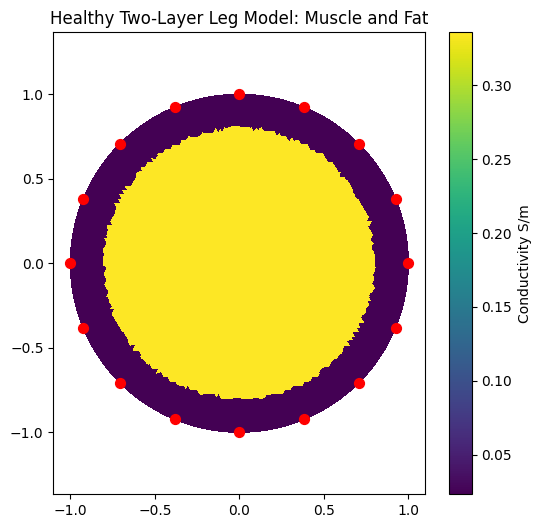

In [8]:
plt.figure(figsize=(6, 6))

plt.tripcolor(
    node[:, 0],
    node[:, 1],
    element,
    mesh_healthy.perm,
    shading="flat"
)

plt.colorbar(label="Conductivity S/m")
plt.scatter(node[el_pos, 0], node[el_pos, 1], c="red", s=50)
plt.title("Healthy Two-Layer Leg Model: Muscle and Fat")
plt.axis("equal")
plt.show()

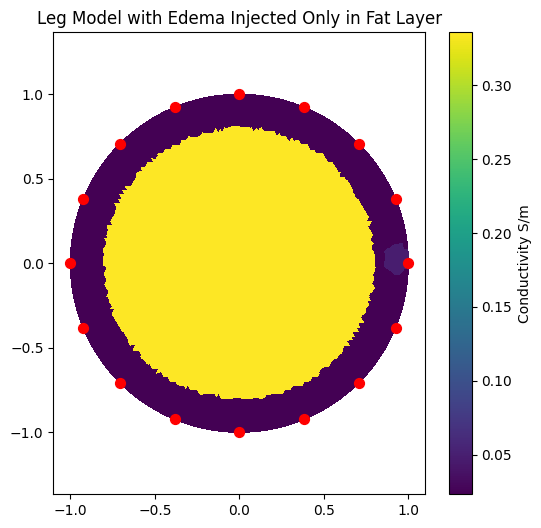

In [9]:
plt.figure(figsize=(6, 6))

plt.tripcolor(
    node[:, 0],
    node[:, 1],
    element,
    mesh_edema.perm,
    shading="flat"
)

plt.colorbar(label="Conductivity S/m")
plt.scatter(node[el_pos, 0], node[el_pos, 1], c="red", s=50)
plt.title("Leg Model with Edema Injected Only in Fat Layer")
plt.axis("equal")
plt.show()

In [ ]:
# plt.figure(figsize=(6, 6))
# plt.tripcolor(
#     node[:, 0],
#     node[:, 1],
#     element,
#     mesh_edema.perm,
#     shading="flat"
# )
# plt.colorbar(label="Conductivity")
# plt.scatter(node[el_pos, 0], node[el_pos, 1], c='red', s=50)
# plt.title("True Simulated Edema Conductivity Distribution")
# plt.axis("equal")
# plt.show()

In [10]:
# -----------------------------
# Forward simulation
# -----------------------------

fwd = EITForward(mesh_obj, protocol_obj)

# # Healthy voltage
# v0 = fwd.solve_eit(perm=mesh_obj.perm)

# # Edema voltage
# v1 = fwd.solve_eit(perm=mesh_edema.perm)
# Healthy voltage: muscle + fat
v0 = fwd.solve_eit(perm=mesh_healthy.perm)

# Diseased voltage: muscle + fat + edema
v1 = fwd.solve_eit(perm=mesh_edema.perm)

# Difference voltage
delta_v = v1 - v0

print("Healthy voltage shape:", v0.shape)
print("Edema voltage shape:", v1.shape)
print("Voltage difference shape:", delta_v.shape)

Healthy voltage shape: (208,)
Edema voltage shape: (208,)
Voltage difference shape: (208,)


In [11]:
def add_noise(signal, snr_db=40):
    """
    Add Gaussian noise according to required SNR.
    """
    signal = np.asarray(signal)
    signal_power = np.linalg.norm(signal) / np.sqrt(signal.size)
    noise_std = signal_power / (10 ** (snr_db / 20))
    noise = np.random.normal(0, noise_std, signal.shape)
    return signal + noise


snr_db = 40
v1_noisy = v0 + add_noise(delta_v, snr_db=snr_db)

print("Noisy voltage generated")

Noisy voltage generated


In [12]:
import os
import json
import time
import copy
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import pyeit.eit.jac as jac

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: NVIDIA RTX A4000


In [14]:
# ---------------------------------------------------------
# Paths and training configuration
# ---------------------------------------------------------

PROJECT_ROOT = Path.cwd()

RESULTS_DIR = PROJECT_ROOT / "results"
PINN_DIR = RESULTS_DIR / "pinn_fat_layer"
CHECKPOINT_DIR = PINN_DIR / "checkpoints"
FIG_DIR = PINN_DIR / "figures"
LOG_DIR = PINN_DIR / "logs"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Use the active case generated above.
# This keeps the old single-case PINN cells working for case_001.
CASE_ID = CURRENT_CASE["case_id"] if "CURRENT_CASE" in globals() else "case_001"

BEST_MODEL_FILE = CHECKPOINT_DIR / f"best_pinn_{CASE_ID}.pt"
LATEST_MODEL_FILE = CHECKPOINT_DIR / f"latest_pinn_{CASE_ID}.pt"
TRAIN_HISTORY_FILE = LOG_DIR / f"train_history_{CASE_ID}.json"
TRAIN_OUTPUT_FILE = CHECKPOINT_DIR / f"pinn_train_output_{CASE_ID}.npz"

# Training configuration
EPOCHS = 20000
LR = 1e-3
PRINT_EVERY = 100
SAVE_EVERY = 500

# Loss weights copied from your existing PINN notebook.
# The PINN model/loss style is intentionally not changed.
LAMBDA_SUP = 100.0
LAMBDA_DATA = 1.0
LAMBDA_SMOOTH = 1e-5
LAMBDA_PRIOR = 0.0
LAMBDA_BG = 50.0
LAMBDA_SPARSE = 1e-3

# Case-specific edema contrast from the generated case.
DELTA_SIGMA_MAX = CURRENT_CASE["delta_sigma_max"] if "CURRENT_CASE" in globals() else 0.045 - 0.022

print("Active CASE_ID:", CASE_ID)
print("DELTA_SIGMA_MAX:", DELTA_SIGMA_MAX)
print("Best model file:", BEST_MODEL_FILE)
print("Latest model file:", LATEST_MODEL_FILE)
print("History file:", TRAIN_HISTORY_FILE)

Active CASE_ID: case_001
DELTA_SIGMA_MAX: 0.02502197466555621
Best model file: /notebooks/case50/results/pinn_fat_layer/checkpoints/best_pinn_case_001.pt
Latest model file: /notebooks/case50/results/pinn_fat_layer/checkpoints/latest_pinn_case_001.pt
History file: /notebooks/case50/results/pinn_fat_layer/logs/train_history_case_001.json


In [15]:
# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [16]:
# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------

def save_json(filepath, obj):
    with open(filepath, "w") as f:
        json.dump(obj, f, indent=2)


def to_tensor(x, dtype=torch.float32):
    return torch.tensor(x, dtype=dtype, device=device)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_stats(name, arr):
    arr = np.asarray(arr)
    print(
        f"{name}: shape={arr.shape}, "
        f"min={arr.min():.6e}, max={arr.max():.6e}, "
        f"mean={arr.mean():.6e}, std={arr.std():.6e}"
    )

In [17]:
# ---------------------------------------------------------
# Build PINN dataset
# ---------------------------------------------------------

# Required variables from previous cells:
required_vars = [
    "mesh_obj", "protocol_obj", "mesh_healthy", "mesh_edema",
    "v0", "v1_noisy", "fat_mask", "edema_mask"
]

missing = [name for name in required_vars if name not in globals()]
if missing:
    raise NameError(f"Missing variables from previous notebook cells: {missing}")

node_2d = mesh_obj.node[:, :2]
element = mesh_obj.element
n_elements = element.shape[0]

# Element center coordinates
region_coords_raw = np.mean(node_2d[element], axis=1).astype(np.float32)

x = region_coords_raw[:, 0]
y = region_coords_raw[:, 1]

r_node = np.sqrt(node_2d[:, 0]**2 + node_2d[:, 1]**2)
r_max = np.max(r_node)

x_norm = x / r_max
y_norm = y / r_max
r_norm = np.sqrt(x_norm**2 + y_norm**2)

# input dimension = 3
# Input = x, y, radial distance
# X_input = np.stack([x_norm, y_norm, r_norm], axis=1).astype(np.float32)
X_input = np.stack([x_norm, y_norm], axis=1).astype(np.float32)

# True conductivity change:
# Healthy = muscle + fat
# Diseased = muscle + fat + edema
# Therefore true delta is non-zero only in edema elements.
delta_sigma_true = (mesh_edema.perm - mesh_healthy.perm).astype(np.float32)
sigma_true = mesh_edema.perm.astype(np.float32)

# Voltage difference
dv = (v1_noisy - v0).astype(np.float32)

# Make sure masks are element-wise float arrays
fat_mask_np = np.asarray(fat_mask).astype(bool)
edema_mask_np = np.asarray(edema_mask).astype(bool)

print("PINN dataset created")
print("X_input shape:", X_input.shape)
print("delta_sigma_true shape:", delta_sigma_true.shape)
print("dv shape:", dv.shape)
print("Number of elements:", n_elements)
print("Fat elements:", np.sum(fat_mask_np))
print("Edema elements:", np.sum(edema_mask_np))
print_stats("delta_sigma_true", delta_sigma_true)

PINN dataset created
X_input shape: (7901, 2)
delta_sigma_true shape: (7901,)
dv shape: (208,)
Number of elements: 7901
Fat elements: 2862
Edema elements: 56
delta_sigma_true: shape=(7901,), min=0.000000e+00, max=2.502197e-02, mean=1.773485e-04, std=2.099085e-03


In [18]:
# ---------------------------------------------------------
# Create homogeneous inverse mesh and obtain Jacobian matrix J
# ---------------------------------------------------------
# Forward model: layered muscle/fat/edema
# PINN inverse model: muscle and fat treated as one normal background

mesh_inverse = copy.deepcopy(mesh_obj)
mesh_inverse.perm = np.ones(n_elements, dtype=np.float32)

eit_pinn = jac.JAC(mesh_inverse, protocol_obj)

eit_pinn.setup(
    p=0.5,
    lamb=0.01,
    method="kotre"
)

def extract_jacobian(eit_obj):
    candidate_names = ["J", "jac", "_J"]
    for name in candidate_names:
        if hasattr(eit_obj, name):
            value = getattr(eit_obj, name)
            if value is not None:
                return np.asarray(value)
    raise AttributeError(
        "Could not find Jacobian matrix in the PyEIT JAC object. "
        "Try checking dir(eit_pinn) after setup()."
    )

J = extract_jacobian(eit_pinn).astype(np.float32)

# Correct orientation if needed
if J.shape[0] != dv.shape[0] and J.shape[1] == dv.shape[0]:
    J = J.T

if J.shape[0] != dv.shape[0]:
    raise ValueError(f"J rows {J.shape[0]} must match voltage measurements {dv.shape[0]}")

if J.shape[1] != n_elements:
    raise ValueError(f"J columns {J.shape[1]} must match mesh elements {n_elements}")

print("Jacobian shape:", J.shape)
print("Voltage difference shape:", dv.shape)
print("Inverse mesh conductivity values:", np.unique(mesh_inverse.perm))

Jacobian shape: (208, 7901)
Voltage difference shape: (208,)
Inverse mesh conductivity values: [1.]


In [19]:
# ---------------------------------------------------------
# Build neighboring region edges for smoothness loss
# ---------------------------------------------------------
# Two triangular elements are neighbors if they share a mesh edge.

def build_element_edges(triangles):
    edge_to_elements = defaultdict(list)

    for ei, tri in enumerate(triangles):
        tri = list(map(int, tri))
        local_edges = [
            tuple(sorted((tri[0], tri[1]))),
            tuple(sorted((tri[1], tri[2]))),
            tuple(sorted((tri[2], tri[0]))),
        ]

        for e in local_edges:
            edge_to_elements[e].append(ei)

    pair_set = set()
    for elems in edge_to_elements.values():
        if len(elems) == 2:
            a, b = elems
            pair_set.add(tuple(sorted((a, b))))

    return np.array(sorted(pair_set), dtype=np.int64)

edges = build_element_edges(element)
degree = np.zeros(n_elements, dtype=np.int32)

for i, j in edges:
    degree[i] += 1
    degree[j] += 1

print("edges shape:", edges.shape)
print("degree shape:", degree.shape)
print("degree min/max:", degree.min(), degree.max())

edges shape: (11746, 2)
degree shape: (7901,)
degree min/max: 2 3


In [20]:
# ---------------------------------------------------------
# Baseline guidance from Jacobian reconstruction
# ---------------------------------------------------------
# baseline reconstruction guides the PINN using prior_guidance_loss.
#
# If variable ds exists from Jacobian reconstruction, it is used.
# Otherwise prior guidance is disabled by zero weights.

edema_delta_value = float(np.max(delta_sigma_true) - np.min(delta_sigma_true))

# if "ds" in globals():
#     delta_sigma_baseline = np.asarray(ds).astype(np.float32).reshape(-1)

#     # Scale baseline to the physical edema contrast scale.
#     max_abs = np.max(np.abs(delta_sigma_baseline)) + 1e-12
#     delta_sigma_baseline = delta_sigma_baseline / max_abs
#     delta_sigma_baseline = delta_sigma_baseline * (0.045 - 0.022)

#     # Guide mainly where baseline magnitude is high and inside fat layer.
#     baseline_guidance_weight = np.abs(delta_sigma_baseline)
#     baseline_guidance_weight = baseline_guidance_weight / (np.max(baseline_guidance_weight) + 1e-12)
#     baseline_guidance_weight = baseline_guidance_weight * fat_mask_np.astype(np.float32)

#     print("Using Jacobian result ds as baseline guidance.")
# else:
delta_sigma_baseline = np.zeros(n_elements, dtype=np.float32)
baseline_guidance_weight = np.zeros(n_elements, dtype=np.float32)

print("No ds variable found. Prior guidance disabled.")

print_stats("delta_sigma_baseline", delta_sigma_baseline)
print_stats("baseline_guidance_weight", baseline_guidance_weight)

No ds variable found. Prior guidance disabled.
delta_sigma_baseline: shape=(7901,), min=0.000000e+00, max=0.000000e+00, mean=0.000000e+00, std=0.000000e+00
baseline_guidance_weight: shape=(7901,), min=0.000000e+00, max=0.000000e+00, mean=0.000000e+00, std=0.000000e+00


In [ ]:
# # ---------------------------------------------------------
# # Convert arrays to torch tensors
# # ---------------------------------------------------------

# X_tensor = to_tensor(X_input)
# delta_sigma_true_tensor = to_tensor(delta_sigma_true).view(-1, 1)
# sigma_true_tensor = to_tensor(sigma_true).view(-1, 1)

# delta_sigma_baseline_tensor = to_tensor(delta_sigma_baseline).view(-1, 1)
# baseline_guidance_weight_tensor = to_tensor(baseline_guidance_weight).view(-1, 1)

# J_tensor = to_tensor(J)
# dv_tensor = to_tensor(dv).view(-1, 1)

# edges_tensor = torch.tensor(edges, dtype=torch.long, device=device)

# fat_mask_tensor = to_tensor(fat_mask_np.astype(np.float32)).view(-1, 1)
# edema_mask_tensor = to_tensor(edema_mask_np.astype(np.float32)).view(-1, 1)
# non_edema_mask_tensor = 1.0 - edema_mask_tensor

# print("edema_mask_tensor:", edema_mask_tensor.shape)
# print("Edema elements:", int(edema_mask_tensor.sum().item()))

# print("Checkpoint: tensors created")
# print("X_tensor:", X_tensor.shape)
# print("delta_sigma_true_tensor:", delta_sigma_true_tensor.shape)
# print("J_tensor:", J_tensor.shape)
# print("dv_tensor:", dv_tensor.shape)
# print("edges_tensor:", edges_tensor.shape)
# # print("fat_mask_tensor:", fat_mask_tensor.shape)

In [21]:
# ---------------------------------------------------------
# Convert arrays to torch tensors
# ---------------------------------------------------------

X_tensor = to_tensor(X_input)

delta_sigma_true_tensor = to_tensor(delta_sigma_true).view(-1, 1)
sigma_true_tensor = to_tensor(sigma_true).view(-1, 1)

delta_sigma_baseline_tensor = to_tensor(delta_sigma_baseline).view(-1, 1)
baseline_guidance_weight_tensor = to_tensor(baseline_guidance_weight).view(-1, 1)

J_tensor = to_tensor(J)
dv_tensor = to_tensor(dv).view(-1, 1)

edges_tensor = torch.tensor(edges, dtype=torch.long, device=device)

fat_mask_tensor = to_tensor(fat_mask_np.astype(np.float32)).view(-1, 1)
edema_mask_tensor = to_tensor(edema_mask_np.astype(np.float32)).view(-1, 1)
non_edema_mask_tensor = 1.0 - edema_mask_tensor

print("Checkpoint: tensors created")
print("X_tensor:", X_tensor.shape)
print("delta_sigma_true_tensor:", delta_sigma_true_tensor.shape)
print("J_tensor:", J_tensor.shape)
print("dv_tensor:", dv_tensor.shape)
print("edges_tensor:", edges_tensor.shape)
print("fat_mask_tensor:", fat_mask_tensor.shape)
print("edema_mask_tensor:", edema_mask_tensor.shape)
print("Edema elements:", int(edema_mask_tensor.sum().item()))

Checkpoint: tensors created
X_tensor: torch.Size([7901, 2])
delta_sigma_true_tensor: torch.Size([7901, 1])
J_tensor: torch.Size([208, 7901])
dv_tensor: torch.Size([208, 1])
edges_tensor: torch.Size([11746, 2])
fat_mask_tensor: torch.Size([7901, 1])
edema_mask_tensor: torch.Size([7901, 1])
Edema elements: 56


In [22]:
# ---------------------------------------------------------
# PINN MLP model
# ---------------------------------------------------------

class PINNMLP(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=128, num_hidden_layers=4, out_dim=1):
        super().__init__()

        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [23]:
model = PINNMLP(
    in_dim=2,
    hidden_dim=128,
    num_hidden_layers=4,
    out_dim=1
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

print(model)
print("Trainable parameters:", count_parameters(model))

PINNMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)
Trainable parameters: 50049


In [ ]:
# # ---------------------------------------------------------
# # Loss functions
# # ---------------------------------------------------------

# mse_loss = nn.MSELoss()

# def supervised_loss(pred_delta_sigma, true_delta_sigma):
#     return mse_loss(pred_delta_sigma, true_delta_sigma)

# def measurement_loss(pred_delta_sigma, J_tensor, dv_tensor):
#     dv_pred = J_tensor @ pred_delta_sigma
#     return mse_loss(dv_pred, dv_tensor), dv_pred

# def smoothness_loss(pred_delta_sigma, edges_tensor):
#     if edges_tensor.shape[0] == 0:
#         return torch.tensor(0.0, device=device)

#     i_idx = edges_tensor[:, 0]
#     j_idx = edges_tensor[:, 1]

#     diff = pred_delta_sigma[i_idx] - pred_delta_sigma[j_idx]
#     return torch.mean(diff ** 2)

# def prior_guidance_loss(pred_delta_sigma, baseline_delta_sigma, guidance_weight):
#     weighted_diff = guidance_weight * (pred_delta_sigma - baseline_delta_sigma) ** 2
#     return torch.mean(weighted_diff)

In [24]:
mse_loss = nn.MSELoss()

def supervised_loss(pred_delta_sigma, true_delta_sigma):
    """
    Weighted supervised loss.
    Edema region is very small, so we give it higher weight.
    """
    weight = 1.0 + 500.0 * edema_mask_tensor
    return torch.mean(weight * (pred_delta_sigma - true_delta_sigma) ** 2)


def measurement_loss(pred_delta_sigma, J_tensor, dv_tensor):
    dv_pred = J_tensor @ pred_delta_sigma
    return mse_loss(dv_pred, dv_tensor), dv_pred


def smoothness_loss(pred_delta_sigma, edges_tensor):
    if edges_tensor.shape[0] == 0:
        return torch.tensor(0.0, device=device)

    i_idx = edges_tensor[:, 0]
    j_idx = edges_tensor[:, 1]

    diff = pred_delta_sigma[i_idx] - pred_delta_sigma[j_idx]
    return torch.mean(diff ** 2)


def background_zero_loss(pred_delta_sigma):
    """
    Force non-edema area to remain close to zero.
    This prevents full fat-ring reconstruction.
    """
    return torch.mean((pred_delta_sigma * non_edema_mask_tensor) ** 2)


def sparsity_loss(pred_delta_sigma):
    """
    Encourage small localized reconstruction instead of full ring.
    """
    return torch.mean(torch.abs(pred_delta_sigma))


def prior_guidance_loss(pred_delta_sigma, baseline_delta_sigma, guidance_weight):
    weighted_diff = guidance_weight * (pred_delta_sigma - baseline_delta_sigma) ** 2
    return torch.mean(weighted_diff)

In [25]:
# ---------------------------------------------------------
# Sanity check before training
# ---------------------------------------------------------

model.eval()
with torch.no_grad():
    raw_pred_delta_sigma_test = model(X_tensor)

    # Restrict reconstruction to fat layer.
    # This makes muscle and fat normal background and reconstructs edema only in fat layer.
    pred_delta_sigma_test = raw_pred_delta_sigma_test * fat_mask_tensor

    l_sup_test = supervised_loss(pred_delta_sigma_test, delta_sigma_true_tensor)
    l_data_test, dv_pred_test = measurement_loss(pred_delta_sigma_test, J_tensor, dv_tensor)
    l_smooth_test = smoothness_loss(pred_delta_sigma_test, edges_tensor)
    l_prior_test = prior_guidance_loss(
        pred_delta_sigma_test,
        delta_sigma_baseline_tensor,
        baseline_guidance_weight_tensor
    )

print("Sanity check losses before training:")
print("supervised loss:", float(l_sup_test.item()))
print("data loss:", float(l_data_test.item()))
print("smoothness loss:", float(l_smooth_test.item()))
print("prior loss:", float(l_prior_test.item()))

Sanity check losses before training:
supervised loss: 0.0032715443521738052
data loss: 0.0009343035635538399
smoothness loss: 6.429057248169556e-05
prior loss: 0.0


In [26]:
# ---------------------------------------------------------
# Training history and checkpoint resume
# ---------------------------------------------------------

history = {
    "epoch": [],
    "total_loss": [],
    "supervised_loss": [],
    "data_loss": [],
    "smoothness_loss": [],
    "prior_loss": []
}

best_loss = float("inf")
start_epoch = 1

# if LATEST_MODEL_FILE.exists():
#     checkpoint = torch.load(LATEST_MODEL_FILE, map_location=device)

#     model.load_state_dict(checkpoint["model_state"])
#     optimizer.load_state_dict(checkpoint["optimizer_state"])
#     history = checkpoint["history"]
#     best_loss = checkpoint["best_loss"]
#     start_epoch = checkpoint["epoch"] + 1

#     print(f"Resumed from checkpoint at epoch {checkpoint['epoch']}")
# else:
print("No previous checkpoint found. Starting fresh.")

No previous checkpoint found. Starting fresh.


In [27]:
# ---------------------------------------------------------
# Train PINN
# ---------------------------------------------------------

start_time = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    raw_pred_delta_sigma = model(X_tensor)

    # Important modification for your current work:
    # reconstruction is forced to appear only in fat layer.
    # Muscle and fat are treated as one normal background.
    # pred_delta_sigma = raw_pred_delta_sigma * fat_mask_tensor

    pred_delta_sigma = DELTA_SIGMA_MAX * torch.sigmoid(raw_pred_delta_sigma)

# Restrict reconstruction to fat layer only
    pred_delta_sigma = pred_delta_sigma * fat_mask_tensor

    l_sup = supervised_loss(pred_delta_sigma, delta_sigma_true_tensor)
    l_data, dv_pred = measurement_loss(pred_delta_sigma, J_tensor, dv_tensor)
    l_smooth = smoothness_loss(pred_delta_sigma, edges_tensor)
    l_prior = prior_guidance_loss(
        pred_delta_sigma,
        delta_sigma_baseline_tensor,
        baseline_guidance_weight_tensor
    )

    # total_loss = (
    #     LAMBDA_SUP * l_sup +
    #     LAMBDA_DATA * l_data +
    #     LAMBDA_SMOOTH * l_smooth +
    #     LAMBDA_PRIOR * l_prior
    # )
    l_bg = background_zero_loss(pred_delta_sigma)
    l_sparse = sparsity_loss(pred_delta_sigma)

    total_loss = (
      LAMBDA_SUP * l_sup +
      LAMBDA_DATA * l_data +
      LAMBDA_SMOOTH * l_smooth +
      LAMBDA_PRIOR * l_prior +
      LAMBDA_BG * l_bg +
      LAMBDA_SPARSE * l_sparse
    )

    total_loss.backward()
    optimizer.step()

    history["epoch"].append(epoch)
    history["total_loss"].append(float(total_loss.item()))
    history["supervised_loss"].append(float(l_sup.item()))
    history["data_loss"].append(float(l_data.item()))
    history["smoothness_loss"].append(float(l_smooth.item()))
    history["prior_loss"].append(float(l_prior.item()))

    if total_loss.item() < best_loss:
        best_loss = float(total_loss.item())
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_loss": best_loss,
            "history": history
        }, BEST_MODEL_FILE)

    if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_loss": best_loss,
            "history": history
        }, LATEST_MODEL_FILE)

        save_json(TRAIN_HISTORY_FILE, history)

    if epoch % PRINT_EVERY == 0 or epoch == 1 or epoch == EPOCHS:
        # print(
        #     f"Epoch {epoch:5d}/{EPOCHS} | "
        #     f"total={total_loss.item():.6e} | "
        #     f"sup={l_sup.item():.6e} | "
        #     f"data={l_data.item():.6e} | "
        #     f"smooth={l_smooth.item():.6e} | "
        #     # f"prior={l_prior.item():.6e}"
        # )
        print(
          f"Epoch {epoch:5d}/{EPOCHS} | "
          f"total={total_loss.item():.6e} | "
          f"sup={l_sup.item():.6e} | "
          f"data={l_data.item():.6e} | "
          f"smooth={l_smooth.item():.6e} | "
          f"bg={l_bg.item():.6e} | "
          f"sparse={l_sparse.item():.6e}"
        )

elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.2f} seconds.")

Epoch     1/20000 | total=6.265442e-02 | sup=5.879047e-04 | data=9.156464e-04 | smooth=2.979298e-06 | bg=5.887289e-05 | sparse=4.663317e-03
Epoch   100/20000 | total=3.828265e-03 | sup=2.046856e-05 | data=9.147411e-04 | smooth=3.277622e-07 | bg=1.731311e-05 | sparse=1.011892e-03
Epoch   200/20000 | total=3.311022e-03 | sup=1.642302e-05 | data=9.131856e-04 | smooth=5.839478e-07 | bg=1.509374e-05 | sparse=8.472780e-04
Epoch   300/20000 | total=2.925101e-03 | sup=1.369244e-05 | data=9.121930e-04 | smooth=7.220183e-07 | bg=1.285862e-05 | sparse=7.335878e-04
Epoch   400/20000 | total=1.922657e-03 | sup=6.946481e-06 | data=9.126984e-04 | smooth=4.925535e-07 | bg=6.297029e-06 | sparse=4.586805e-04
Epoch   500/20000 | total=1.239041e-03 | sup=2.290176e-06 | data=9.129859e-04 | smooth=3.315614e-07 | bg=1.935279e-06 | sparse=2.735287e-04
Epoch   600/20000 | total=2.404300e-03 | sup=9.925109e-06 | data=9.149488e-04 | smooth=1.034796e-06 | bg=9.925109e-06 | sparse=5.851781e-04
Epoch   700/20000 | 

In [28]:
# ---------------------------------------------------------
# Load best model and evaluate
# ---------------------------------------------------------

best_checkpoint = torch.load(BEST_MODEL_FILE, map_location=device)
model.load_state_dict(best_checkpoint["model_state"])
model.eval()

print("Best model loaded from:", BEST_MODEL_FILE)
print("Best loss:", best_checkpoint["best_loss"])

with torch.no_grad():
    raw_pred_delta_sigma = model(X_tensor)
    # pred_delta_sigma = raw_pred_delta_sigma * fat_mask_tensor
    pred_delta_sigma = DELTA_SIGMA_MAX * torch.sigmoid(raw_pred_delta_sigma)
    pred_delta_sigma = pred_delta_sigma * fat_mask_tensor

    final_sup_loss = supervised_loss(pred_delta_sigma, delta_sigma_true_tensor)
    final_data_loss, final_dv_pred = measurement_loss(pred_delta_sigma, J_tensor, dv_tensor)
    final_smooth_loss = smoothness_loss(pred_delta_sigma, edges_tensor)
    final_prior_loss = prior_guidance_loss(
        pred_delta_sigma,
        delta_sigma_baseline_tensor,
        baseline_guidance_weight_tensor
    )

pred_delta_sigma_np = pred_delta_sigma.detach().cpu().numpy().reshape(-1)
final_dv_pred_np = final_dv_pred.detach().cpu().numpy().reshape(-1)

print("Final evaluation losses:")
print("supervised loss:", float(final_sup_loss.item()))
print("data loss:", float(final_data_loss.item()))
print("smoothness loss:", float(final_smooth_loss.item()))
print("prior loss:", float(final_prior_loss.item()))

print_stats("pred_delta_sigma_np", pred_delta_sigma_np)
print_stats("final_dv_pred_np", final_dv_pred_np)

Best model loaded from: /notebooks/case50/results/pinn_fat_layer/checkpoints/best_pinn_case_001.pt
Best loss: 0.0010182926198467612
Final evaluation losses:
supervised loss: 3.881484644807642e-06
data loss: 0.0009138413006439805
smoothness loss: 1.084863129108271e-06
prior loss: 0.0
pred_delta_sigma_np: shape=(7901,), min=0.000000e+00, max=2.502197e-02, mean=3.331996e-04, std=2.864974e-03
final_dv_pred_np: shape=(208,), min=-1.405715e-04, max=5.817597e-04, mean=1.255629e-05, std=7.493713e-05


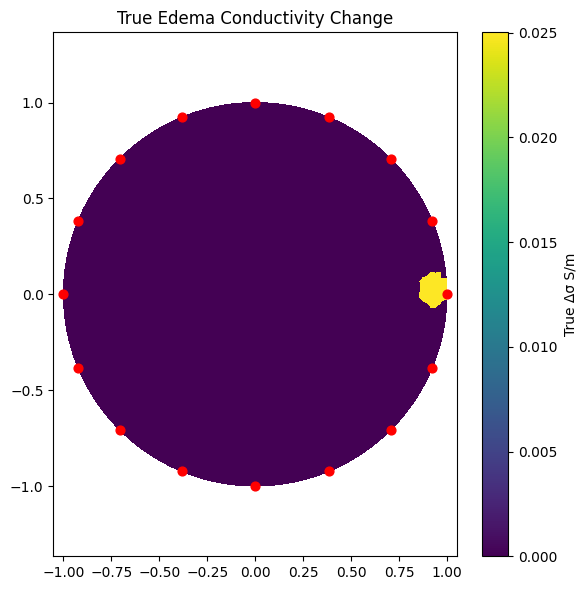

Saved: /notebooks/case50/results/pinn_fat_layer/figures/case_001_true_delta_sigma.png


In [29]:
# ---------------------------------------------------------
# Plot true edema delta and PINN reconstructed delta
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.tripcolor(
    node_2d[:, 0],
    node_2d[:, 1],
    element,
    delta_sigma_true,
    shading="flat"
)
plt.colorbar(label="True Δσ S/m")
plt.scatter(node_2d[mesh_obj.el_pos, 0], node_2d[mesh_obj.el_pos, 1], c="red", s=40)
plt.title("True Edema Conductivity Change")
plt.axis("equal")
plt.tight_layout()

fig_path = FIG_DIR / f"{CASE_ID}_true_delta_sigma.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

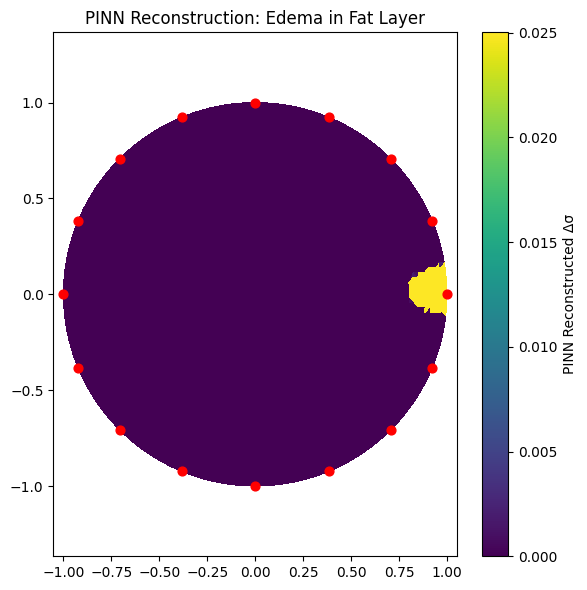

Saved: /notebooks/case50/results/pinn_fat_layer/figures/case_001_pinn_reconstruction.png


In [30]:
plt.figure(figsize=(6, 6))
plt.tripcolor(
    node_2d[:, 0],
    node_2d[:, 1],
    element,
    pred_delta_sigma_np,
    shading="flat"
)
plt.colorbar(label="PINN Reconstructed Δσ")
plt.scatter(node_2d[mesh_obj.el_pos, 0], node_2d[mesh_obj.el_pos, 1], c="red", s=40)
plt.title("PINN Reconstruction: Edema in Fat Layer")
plt.axis("equal")
plt.tight_layout()

fig_path = FIG_DIR / f"{CASE_ID}_pinn_reconstruction.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

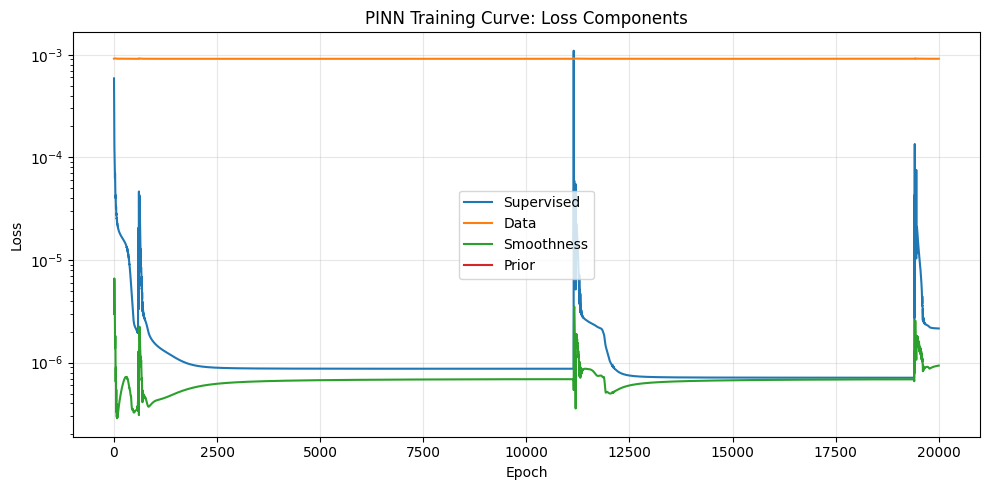

Saved: /notebooks/case50/results/pinn_fat_layer/figures/case_001_pinn_loss_components.png


In [31]:
plt.figure(figsize=(10, 5))
plt.plot(history["epoch"], history["supervised_loss"], label="Supervised")
plt.plot(history["epoch"], history["data_loss"], label="Data")
plt.plot(history["epoch"], history["smoothness_loss"], label="Smoothness")
plt.plot(history["epoch"], history["prior_loss"], label="Prior")
plt.title("PINN Training Curve: Loss Components")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / f"{CASE_ID}_pinn_loss_components.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

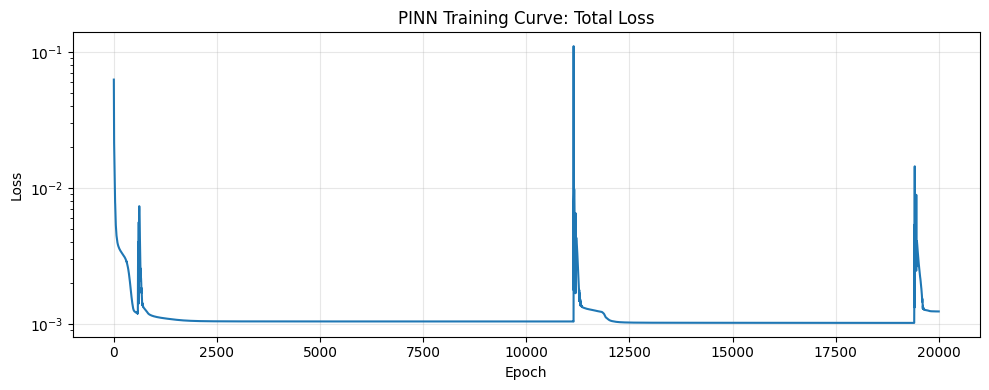

Saved: /notebooks/case50/results/pinn_fat_layer/figures/case_001_pinn_total_loss.png


In [32]:
# ---------------------------------------------------------
# Plot training curves
# ---------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(history["epoch"], history["total_loss"])
plt.title("PINN Training Curve: Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / f"{CASE_ID}_pinn_total_loss.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [33]:
# ---------------------------------------------------------
# Save training output
# ---------------------------------------------------------

np.savez(
    TRAIN_OUTPUT_FILE,
    pred_delta_sigma=pred_delta_sigma_np.astype(np.float32),
    dv_pred=final_dv_pred_np.astype(np.float32),
    delta_sigma_true=delta_sigma_true.astype(np.float32),
    edema_mask_true=edema_mask_np.astype(np.float32),
    fat_mask=fat_mask_np.astype(np.float32),
    X_input=X_input.astype(np.float32),
    J=J.astype(np.float32),
    dv=dv.astype(np.float32),
    edges=edges.astype(np.int32),
    epoch=np.array([best_checkpoint["epoch"]], dtype=np.int32),
    best_loss=np.array([best_checkpoint["best_loss"]], dtype=np.float32),
    final_supervised_loss=np.array([final_sup_loss.item()], dtype=np.float32),
    final_data_loss=np.array([final_data_loss.item()], dtype=np.float32),
    final_smoothness_loss=np.array([final_smooth_loss.item()], dtype=np.float32),
    final_prior_loss=np.array([final_prior_loss.item()], dtype=np.float32),
)

print("Saved training output to:", TRAIN_OUTPUT_FILE)

Saved training output to: /notebooks/case50/results/pinn_fat_layer/checkpoints/pinn_train_output_case_001.npz


In [ ]:
# ---------------------------------------------------------
# Run remaining 49 cases using the same PINN model and same loss style
# ---------------------------------------------------------
# IMPORTANT:
# 1. First check the output of case_001 from the cells above.
# 2. Then set RUN_REMAINING_49 = True and run this cell.
# ---------------------------------------------------------

# RUN_REMAINING_49 = False
RUN_REMAINING_49 = True

def run_case_with_same_pinn(case_config, plot_result=True):
    """
    Run one generated case using the same PINN model architecture,
    same loss functions, and same training style as the first case.

    Only the edema generation and case-specific conductivity values are changed.
    """

    global CASE_ID, BEST_MODEL_FILE, LATEST_MODEL_FILE, TRAIN_HISTORY_FILE, TRAIN_OUTPUT_FILE
    global CURRENT_CASE, DELTA_SIGMA_MAX
    global mesh_healthy, mesh_edema, muscle_mask, fat_mask, edema_mask
    global v0, v1, delta_v, v1_noisy
    global X_tensor, delta_sigma_true_tensor, sigma_true_tensor
    global delta_sigma_baseline_tensor, baseline_guidance_weight_tensor
    global J_tensor, dv_tensor, edges_tensor
    global fat_mask_tensor, edema_mask_tensor, non_edema_mask_tensor
    global model, optimizer, history, best_loss, start_epoch
    global pred_delta_sigma_np, final_dv_pred_np

    CURRENT_CASE = case_config
    CASE_ID = case_config["case_id"]
    DELTA_SIGMA_MAX = case_config["delta_sigma_max"]

    print("\n" + "=" * 80)
    print("Running:", CASE_ID)
    print(case_config)

    # -----------------------------------------------------
    # Create healthy and diseased meshes for this case
    # -----------------------------------------------------
    mesh_healthy, mesh_edema, muscle_mask, fat_mask, edema_mask = create_layered_leg_with_edema(
        mesh_obj,
        edema_center=case_config["edema_center"],
        edema_radius=case_config["edema_radius"],
        sigma_fat=case_config["sigma_fat"],
        sigma_muscle=case_config["sigma_muscle"],
        sigma_edema=case_config["sigma_edema"],
        muscle_boundary=MUSCLE_BOUNDARY
    )

    # -----------------------------------------------------
    # Forward simulation
    # -----------------------------------------------------
    fwd = EITForward(mesh_obj, protocol_obj)

    v0 = fwd.solve_eit(perm=mesh_healthy.perm)
    v1 = fwd.solve_eit(perm=mesh_edema.perm)
    delta_v = v1 - v0

    v1_noisy = v0 + add_noise(delta_v, snr_db=snr_db)

    # -----------------------------------------------------
    # Dataset preparation
    # Same logic as the first case
    # -----------------------------------------------------
    node_2d = mesh_obj.node[:, :2]
    element = mesh_obj.element
    n_elements = element.shape[0]

    region_coords_raw = np.mean(node_2d[element], axis=1).astype(np.float32)

    x = region_coords_raw[:, 0]
    y = region_coords_raw[:, 1]

    r_node = np.sqrt(node_2d[:, 0]**2 + node_2d[:, 1]**2)
    r_max = np.max(r_node)

    x_norm = x / r_max
    y_norm = y / r_max

    # Neural input remains only x and y.
    X_input = np.stack([x_norm, y_norm], axis=1).astype(np.float32)

    delta_sigma_true = (mesh_edema.perm - mesh_healthy.perm).astype(np.float32)
    sigma_true = mesh_edema.perm.astype(np.float32)

    dv = (v1_noisy - v0).astype(np.float32)

    fat_mask_np = np.asarray(fat_mask).astype(bool)
    edema_mask_np = np.asarray(edema_mask).astype(bool)

    # -----------------------------------------------------
    # Jacobian
    # Same as your current notebook: homogeneous inverse mesh.
    # PINN model is not changed.
    # -----------------------------------------------------
    mesh_inverse = copy.deepcopy(mesh_obj)
    mesh_inverse.perm = np.ones(n_elements, dtype=np.float32)

    eit_pinn = jac.JAC(mesh_inverse, protocol_obj)

    eit_pinn.setup(
        p=0.5,
        lamb=0.01,
        method="kotre"
    )

    J = extract_jacobian(eit_pinn).astype(np.float32)

    if J.shape[0] != dv.shape[0] and J.shape[1] == dv.shape[0]:
        J = J.T

    if J.shape[0] != dv.shape[0]:
        raise ValueError(f"J rows {J.shape[0]} must match voltage measurements {dv.shape[0]}")

    if J.shape[1] != n_elements:
        raise ValueError(f"J columns {J.shape[1]} must match mesh elements {n_elements}")

    # -----------------------------------------------------
    # Edges
    # -----------------------------------------------------
    edges = build_element_edges(element)

    # -----------------------------------------------------
    # Baseline guidance disabled, same as first case
    # -----------------------------------------------------
    delta_sigma_baseline = np.zeros(n_elements, dtype=np.float32)
    baseline_guidance_weight = np.zeros(n_elements, dtype=np.float32)

    # -----------------------------------------------------
    # Tensors
    # -----------------------------------------------------
    X_tensor = to_tensor(X_input)

    delta_sigma_true_tensor = to_tensor(delta_sigma_true).view(-1, 1)
    sigma_true_tensor = to_tensor(sigma_true).view(-1, 1)

    delta_sigma_baseline_tensor = to_tensor(delta_sigma_baseline).view(-1, 1)
    baseline_guidance_weight_tensor = to_tensor(baseline_guidance_weight).view(-1, 1)

    J_tensor = to_tensor(J)
    dv_tensor = to_tensor(dv).view(-1, 1)

    edges_tensor = torch.tensor(edges, dtype=torch.long, device=device)

    fat_mask_tensor = to_tensor(fat_mask_np.astype(np.float32)).view(-1, 1)
    edema_mask_tensor = to_tensor(edema_mask_np.astype(np.float32)).view(-1, 1)
    non_edema_mask_tensor = 1.0 - edema_mask_tensor

    # -----------------------------------------------------
    # New model per case, same PINN architecture
    # -----------------------------------------------------
    model = PINNMLP(
        in_dim=2,
        hidden_dim=128,
        num_hidden_layers=4,
        out_dim=1
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LR)

    # -----------------------------------------------------
    # Training history
    # -----------------------------------------------------
    history = {
        "epoch": [],
        "total_loss": [],
        "supervised_loss": [],
        "data_loss": [],
        "smoothness_loss": [],
        "prior_loss": []
    }

    best_loss = float("inf")
    start_epoch = 1

    BEST_MODEL_FILE = CHECKPOINT_DIR / f"best_pinn_{CASE_ID}.pt"
    LATEST_MODEL_FILE = CHECKPOINT_DIR / f"latest_pinn_{CASE_ID}.pt"
    TRAIN_HISTORY_FILE = LOG_DIR / f"train_history_{CASE_ID}.json"
    TRAIN_OUTPUT_FILE = CHECKPOINT_DIR / f"pinn_train_output_{CASE_ID}.npz"

    # -----------------------------------------------------
    # Train PINN: same logic as the first case
    # -----------------------------------------------------
    start_time = time.time()

    for epoch in range(start_epoch, EPOCHS + 1):
        model.train()
        optimizer.zero_grad()

        raw_pred_delta_sigma = model(X_tensor)

        pred_delta_sigma = DELTA_SIGMA_MAX * torch.sigmoid(raw_pred_delta_sigma)

        # Restrict reconstruction to fat layer only
        pred_delta_sigma = pred_delta_sigma * fat_mask_tensor

        l_sup = supervised_loss(pred_delta_sigma, delta_sigma_true_tensor)
        l_data, dv_pred = measurement_loss(pred_delta_sigma, J_tensor, dv_tensor)
        l_smooth = smoothness_loss(pred_delta_sigma, edges_tensor)
        l_prior = prior_guidance_loss(
            pred_delta_sigma,
            delta_sigma_baseline_tensor,
            baseline_guidance_weight_tensor
        )

        l_bg = background_zero_loss(pred_delta_sigma)
        l_sparse = sparsity_loss(pred_delta_sigma)

        total_loss = (
            LAMBDA_SUP * l_sup +
            LAMBDA_DATA * l_data +
            LAMBDA_SMOOTH * l_smooth +
            LAMBDA_PRIOR * l_prior +
            LAMBDA_BG * l_bg +
            LAMBDA_SPARSE * l_sparse
        )

        total_loss.backward()
        optimizer.step()

        history["epoch"].append(epoch)
        history["total_loss"].append(float(total_loss.item()))
        history["supervised_loss"].append(float(l_sup.item()))
        history["data_loss"].append(float(l_data.item()))
        history["smoothness_loss"].append(float(l_smooth.item()))
        history["prior_loss"].append(float(l_prior.item()))

        if total_loss.item() < best_loss:
            best_loss = float(total_loss.item())
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_loss": best_loss,
                "history": history
            }, BEST_MODEL_FILE)

        if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_loss": best_loss,
                "history": history
            }, LATEST_MODEL_FILE)

            save_json(TRAIN_HISTORY_FILE, history)

        if epoch % PRINT_EVERY == 0 or epoch == 1 or epoch == EPOCHS:
            print(
                f"Epoch {epoch:5d}/{EPOCHS} | "
                f"total={total_loss.item():.6e} | "
                f"sup={l_sup.item():.6e} | "
                f"data={l_data.item():.6e} | "
                f"smooth={l_smooth.item():.6e} | "
                f"bg={l_bg.item():.6e} | "
                f"sparse={l_sparse.item():.6e}"
            )

    elapsed = time.time() - start_time
    print(f"{CASE_ID} training completed in {elapsed:.2f} seconds.")

    # -----------------------------------------------------
    # Load best model and evaluate
    # -----------------------------------------------------
    best_checkpoint = torch.load(BEST_MODEL_FILE, map_location=device)
    model.load_state_dict(best_checkpoint["model_state"])
    model.eval()

    with torch.no_grad():
        raw_pred_delta_sigma = model(X_tensor)
        pred_delta_sigma = DELTA_SIGMA_MAX * torch.sigmoid(raw_pred_delta_sigma)
        pred_delta_sigma = pred_delta_sigma * fat_mask_tensor

        final_sup_loss = supervised_loss(pred_delta_sigma, delta_sigma_true_tensor)
        final_data_loss, final_dv_pred = measurement_loss(pred_delta_sigma, J_tensor, dv_tensor)
        final_smooth_loss = smoothness_loss(pred_delta_sigma, edges_tensor)
        final_prior_loss = prior_guidance_loss(
            pred_delta_sigma,
            delta_sigma_baseline_tensor,
            baseline_guidance_weight_tensor
        )

    pred_delta_sigma_np = pred_delta_sigma.detach().cpu().numpy().reshape(-1)
    final_dv_pred_np = final_dv_pred.detach().cpu().numpy().reshape(-1)

    # -----------------------------------------------------
    # Save figures
    # -----------------------------------------------------
    if plot_result:
        plt.figure(figsize=(6, 6))
        plt.tripcolor(
            node_2d[:, 0],
            node_2d[:, 1],
            element,
            delta_sigma_true,
            shading="flat"
        )
        plt.colorbar(label="True Δσ S/m")
        plt.scatter(node_2d[mesh_obj.el_pos, 0], node_2d[mesh_obj.el_pos, 1], c="red", s=40)
        plt.title(f"{CASE_ID}: True Edema Conductivity Change")
        plt.axis("equal")
        plt.tight_layout()
        fig_path = FIG_DIR / f"{CASE_ID}_true_delta_sigma.png"
        plt.savefig(fig_path, dpi=200, bbox_inches="tight")
        plt.close()

        plt.figure(figsize=(6, 6))
        plt.tripcolor(
            node_2d[:, 0],
            node_2d[:, 1],
            element,
            pred_delta_sigma_np,
            shading="flat"
        )
        plt.colorbar(label="PINN Reconstructed Δσ")
        plt.scatter(node_2d[mesh_obj.el_pos, 0], node_2d[mesh_obj.el_pos, 1], c="red", s=40)
        plt.title(f"{CASE_ID}: PINN Reconstruction")
        plt.axis("equal")
        plt.tight_layout()
        fig_path = FIG_DIR / f"{CASE_ID}_pinn_reconstruction.png"
        plt.savefig(fig_path, dpi=200, bbox_inches="tight")
        plt.close()

        plt.figure(figsize=(10, 4))
        plt.plot(history["epoch"], history["total_loss"])
        plt.title(f"{CASE_ID}: PINN Training Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.yscale("log")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        fig_path = FIG_DIR / f"{CASE_ID}_pinn_total_loss.png"
        plt.savefig(fig_path, dpi=200, bbox_inches="tight")
        plt.close()

    # -----------------------------------------------------
    # Save output
    # -----------------------------------------------------
    np.savez(
        TRAIN_OUTPUT_FILE,
        pred_delta_sigma=pred_delta_sigma_np.astype(np.float32),
        dv_pred=final_dv_pred_np.astype(np.float32),
        delta_sigma_true=delta_sigma_true.astype(np.float32),
        edema_mask_true=edema_mask_np.astype(np.float32),
        fat_mask=fat_mask_np.astype(np.float32),
        X_input=X_input.astype(np.float32),
        J=J.astype(np.float32),
        dv=dv.astype(np.float32),
        edges=edges.astype(np.int32),
        epoch=np.array([best_checkpoint["epoch"]], dtype=np.int32),
        best_loss=np.array([best_checkpoint["best_loss"]], dtype=np.float32),
        final_supervised_loss=np.array([final_sup_loss.item()], dtype=np.float32),
        final_data_loss=np.array([final_data_loss.item()], dtype=np.float32),
        final_smoothness_loss=np.array([final_smooth_loss.item()], dtype=np.float32),
        final_prior_loss=np.array([final_prior_loss.item()], dtype=np.float32),
    )

    case_result = {
        "case_id": CASE_ID,
        "edema_center_x": case_config["edema_center"][0],
        "edema_center_y": case_config["edema_center"][1],
        "edema_radius": case_config["edema_radius"],
        "sigma_fat": case_config["sigma_fat"],
        "sigma_muscle": case_config["sigma_muscle"],
        "sigma_edema": case_config["sigma_edema"],
        "delta_sigma_max": case_config["delta_sigma_max"],
        "edema_elements": int(edema_mask_np.sum()),
        "best_epoch": int(best_checkpoint["epoch"]),
        "best_loss": float(best_checkpoint["best_loss"]),
        "final_supervised_loss": float(final_sup_loss.item()),
        "final_data_loss": float(final_data_loss.item()),
        "final_smoothness_loss": float(final_smooth_loss.item()),
        "pred_delta_min": float(pred_delta_sigma_np.min()),
        "pred_delta_max": float(pred_delta_sigma_np.max()),
        "pred_delta_mean": float(pred_delta_sigma_np.mean())
    }

    return case_result


if not RUN_REMAINING_49:
    print("Remaining 49 cases not started.")
    print("Check the output of case_001 first.")
    print("Then set RUN_REMAINING_49 = True in this cell and run again.")
else:
    all_results = []

    # Save metadata for all generated cases
    case_table = pd.DataFrame(CASE_LIST)
    case_table.to_csv(PINN_DIR / "generated_50_case_metadata.csv", index=False)

    for case_config in CASE_LIST[1:]:
        result = run_case_with_same_pinn(case_config, plot_result=True)
        all_results.append(result)

    results_df = pd.DataFrame(all_results)
    results_df.to_csv(PINN_DIR / "remaining_49_case_results.csv", index=False)

    print("Completed remaining 49 cases.")
    print("Saved result summary:", PINN_DIR / "remaining_49_case_results.csv")
    display(results_df)


Running: case_002
{'case_id': 'case_002', 'edema_center': (0.9251155257225037, 0.16766680777072906), 'edema_radius': 0.0768512328052432, 'sigma_fat': 0.020363699983772403, 'sigma_muscle': 0.3366262437768986, 'sigma_edema': 0.04383718221809323, 'delta_sigma_max': 0.02347348223432083, 'estimated_edema_elements': 46}
Layered leg model created
Muscle elements: 5039
Fat elements: 2862
Edema elements: 46
sigma_muscle: 0.3366262437768986
sigma_fat: 0.020363699983772403
sigma_edema: 0.04383718221809323
Delta sigma max: 0.02347348223432083
Healthy conductivity values: [0.0203637  0.33662623]
Diseased conductivity values: [0.0203637  0.04383718 0.33662623]
Epoch     1/20000 | total=4.722876e-02 | sup=4.367467e-04 | data=1.093290e-03 | smooth=2.477273e-06 | bg=4.913098e-05 | sparse=4.253779e-03
Epoch   100/20000 | total=3.512900e-03 | sup=1.690079e-05 | data=1.091649e-03 | smooth=2.968204e-07 | bg=1.460575e-05 | sparse=8.843966e-04
Epoch   200/20000 | total=3.141494e-03 | sup=1.403835e-05 | data